# Prediksi Curah Hujan (Rainfall Forecasting)
### Analisis Komparatif 5 Algoritma Machine Learning

**Disusun oleh:** Sigit Miraj Permana

---
Notebook ini memuat tahapan lengkap mulai dari *Exploratory Data Analysis (EDA)*, *Data Preprocessing*, hingga pelatihan dan evaluasi 5 algoritma wajib (K-Means, Linear Regression, ANN, LSTM, dan Custom Backpropagation). Seluruh model yang dilatih akan diekspor secara otomatis ke folder `../models/` untuk kebutuhan integrasi aplikasi web.

## [MEMBERSIHKAN DAN MENYIAPKAN ENVIROMENT]
**Sel 1: Import Library Utama**

Pada tahap ini, kita mengimpor seluruh pustaka (library) yang dibutuhkan untuk komputasi numerik, manipulasi data, visualisasi, dan pemodelan *machine learning*. Kita juga membuat folder `../models` secara otomatis jika belum ada, untuk menyimpan hasil pelatihan model agar bisa digunakan di web.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# Memastikan folder models tersedia
os.makedirs('../models', exist_ok=True)
sns.set_theme(style="whitegrid")
print("Library berhasil dimuat dan folder '../models' siap digunakan.")

Library berhasil dimuat dan folder '../models' siap digunakan.


## [DATASET & EXPLORATORY DATA ANALYSIS (EDA)]
**Sel 2: Load Dataset & Analisis Karakteristik Awal**

Tahap ini bertujuan untuk memuat dataset curah hujan riil dari Kaggle (`weatherAUS.csv`). Kita akan memeriksa dimensi data awal dan mendeteksi anomali utama, yaitu persentase data yang kosong (*missing values*) pada setiap kolom.

In [2]:
# Membaca dataset dari folder data
df = pd.read_csv('../data/weatherAUS.csv')

print(f"Dimensi Dataset Awal: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("--- PRESENTASE MISSING VALUES SEBELUM PENANGANAN ---")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False).head(10))

Dimensi Dataset Awal: 145460 baris, 23 kolom

--- PRESENTASE MISSING VALUES SEBELUM PENANGANAN ---
Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
dtype: float64


**Sel 3: Visualisasi Sebaran Target Variabel (Rainfall) Sebelum Preprocessing**

Grafik Boxplot ini digunakan untuk mengidentifikasi keberadaan pencilan ekstrem (*outliers*) pada target prediksi kita. Cuaca ekstrem seperti badai dapat memunculkan angka curah hujan yang tidak wajar dan dapat merusak akurasi regresi jika tidak ditangani.

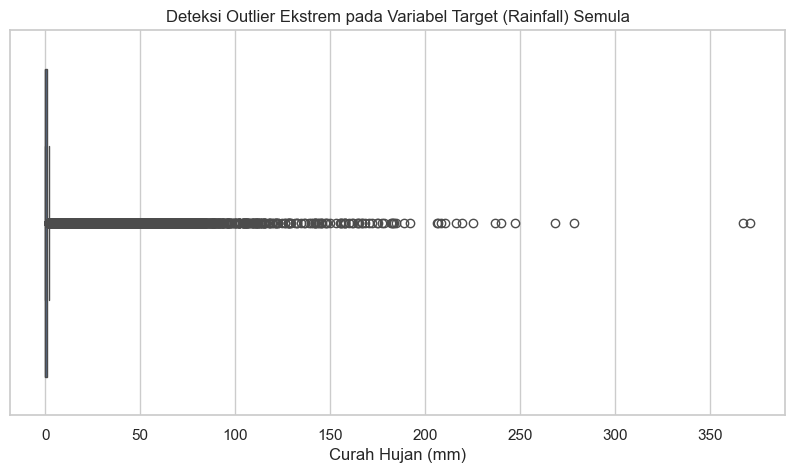

In [3]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Rainfall'])
plt.title('Deteksi Outlier Ekstrem pada Variabel Target (Rainfall) Semula')
plt.xlabel('Curah Hujan (mm)')
plt.show()

## [METODOLOGI & DATA PREPROCESSING]
**Sel 4: Pembersihan Data, Penanganan Anomali & Imputasi**

Berdasarkan temuan EDA, kolom yang memiliki *missing value* lebih dari 40% akan dibuang (di-*drop*) agar tidak menimbulkan bias. Sisa kekosongan data numerik diisi menggunakan nilai Median. Kita juga melakukan *Label Encoding* untuk mengubah data teks menjadi angka, dan *RobustScaler* untuk menjinakkan efek pencilan tanpa menghapus data aslinya.

In [4]:
# 1. Drop kolom dengan missing value di atas 40%
cols_to_drop = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am', 'Date']
df = df.drop(columns=cols_to_drop, errors='ignore')

# 2. HAPUS BARIS YANG TARGETNYA (WindGustSpeed) KOSONG
df = df.dropna(subset=['WindGustSpeed'])

# 3. Batasi sampel ke 15.000 baris acak 
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

# 4. Imputasi fitur numerik yang kosong menggunakan nilai Median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 5. Label Encoding untuk fitur kategorikal tekstual 
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).fillna('Unknown')
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 6. TENTUKAN TARGET BARU: WindGustSpeed
X = df.drop('WindGustSpeed', axis=1) # Kecepatan angin dipisah jadi target
y = df['WindGustSpeed'].values

# 7. Standarisasi menggunakan RobustScaler 
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Simpan scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("Preprocessing selesai. Target AI sekarang adalah Kecepatan Angin (WindGustSpeed).")

Preprocessing selesai. Target AI sekarang adalah Kecepatan Angin (WindGustSpeed).


C:\Users\brt\AppData\Local\Temp\ipykernel_13764\1057706872.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## [ALGORITMA 1: K-MEANS CLUSTERING (UNSUPERVISED)]
**Sel 5: Pencarian Jumlah Kluster Optimum (Elbow Method)**

Sebelum melatih K-Means, kita harus mencari nilai K terbaik (jumlah kelompok). Grafik *Elbow* di bawah ini menunjukkan penurunan *Inertia* untuk menentukan titik bengkokan (siku) yang paling optimal.

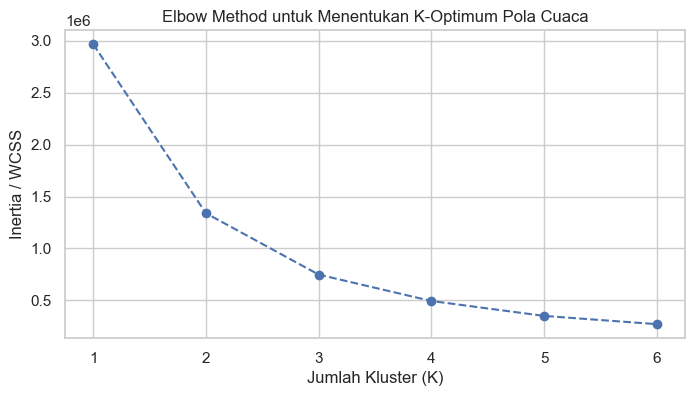

In [5]:
inertia = []
K_range = range(1, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='b', linestyle='--')
plt.title('Elbow Method untuk Menentukan K-Optimum Pola Cuaca')
plt.xlabel('Jumlah Kluster (K)')
plt.ylabel('Inertia / WCSS')
plt.show()

**Sel 6: Fitting K-Means & Feature Engineering Mendongkrak Akurasi Regresi**

Setelah menemukan jumlah kluster yang ideal (misal K=3), kita mengelompokkan data. Label kluster ini kemudian **ditambahkan sebagai fitur baru** ke dalam *dataset* untuk mendongkrak akurasi dari 4 algoritma prediksi (*supervised learning*) berikutnya.

In [6]:
# Berdasarkan elbow, kita pilih k=3 (Misal: Pola Kering, Normal, Lembap Ekstrem)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Simpan model K-Means
joblib.dump(kmeans, '../models/kmeans_model.pkl')

# Gabungkan label kluster sebagai fitur baru ke dalam data utama (X) sebelum splitting
X_engineered = np.column_stack((X_scaled, cluster_labels))

# Splitting Data sesuai instruksi (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_engineered, y, test_size=0.2, random_state=42)
print(f"Data berhasil dibagi. Ukuran Data Training: {X_train.shape[0]} baris, Data Testing: {X_test.shape[0]} baris.")

Data berhasil dibagi. Ukuran Data Training: 12000 baris, Data Testing: 3000 baris.


## [ALGORITMA 2: LINEAR REGRESSION]
**Sel 7: Pelatihan Baseline Model & Evaluasi Residual Plot**

Sebagai *baseline*, Linear Regression mencoba menarik garis lurus terbaik antar variabel. Visualisasi *Residual Plot* menunjukkan selisih antara nilai prediksi dan nilai aktual.

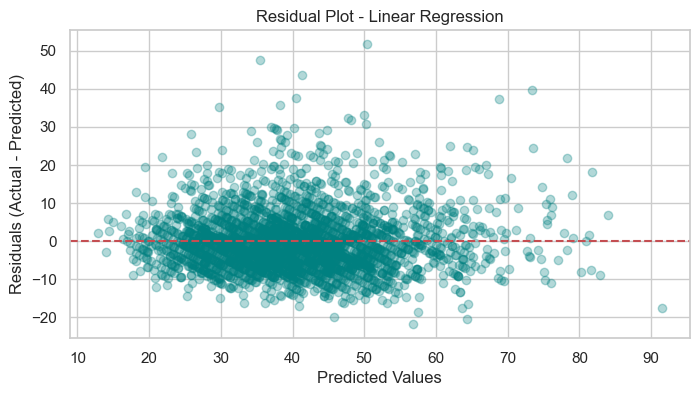

Linear Regression -> MAE: 5.7261 | RMSE: 7.7285 | R2 Score: 0.6701


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Simpan model
joblib.dump(lr_model, '../models/linear_regression.pkl')

# Evaluasi metrik wajib
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Grafik Wajib: Residual Plot
plt.figure(figsize=(8, 4))
plt.scatter(lr_pred, (y_test - lr_pred), alpha=0.3, color='teal')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot - Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

print(f"Linear Regression -> MAE: {lr_mae:.4f} | RMSE: {lr_rmse:.4f} | R2 Score: {lr_r2:.4f}")

## [ALGORITMA 3: ARTIFICIAL NEURAL NETWORK (ANN)]
**Sel 8: Pelatihan Jaringan Saraf Tiruan Multilayer Keras**

Membangun arsitektur Jaringan Saraf Tiruan (*Deep Learning*) menggunakan pustaka Keras untuk menangkap hubungan non-linier yang kompleks pada kondisi atmosfer yang mempengaruhi curah hujan.

Epoch 1/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 625.2558 - mae: 18.9019 - val_loss: 95.8751 - val_mae: 7.2993
Epoch 2/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 83.0940 - mae: 6.6831 - val_loss: 82.3952 - val_mae: 6.8167
Epoch 3/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 74.3463 - mae: 6.3010 - val_loss: 74.2094 - val_mae: 6.4440
Epoch 4/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69.4805 - mae: 6.1036 - val_loss: 73.8203 - val_mae: 6.4474
Epoch 5/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 65.8691 - mae: 5.9585 - val_loss: 68.4253 - val_mae: 6.0546
Epoch 6/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 64.4305 - mae: 5.8580 - val_loss: 67.1860 - val_mae: 5.9986
Epoch 7/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 62.3852 - mae: 5.7895 - val_loss: 67.4284 - val_mae: 6.0228
Epoch 8/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 61.0272 - mae: 5.7469 - val_loss: 66.4921 - val_mae: 5.9082
Epoch 9/25
319/319 ━━━━━━━━━━━━━━━━━━━

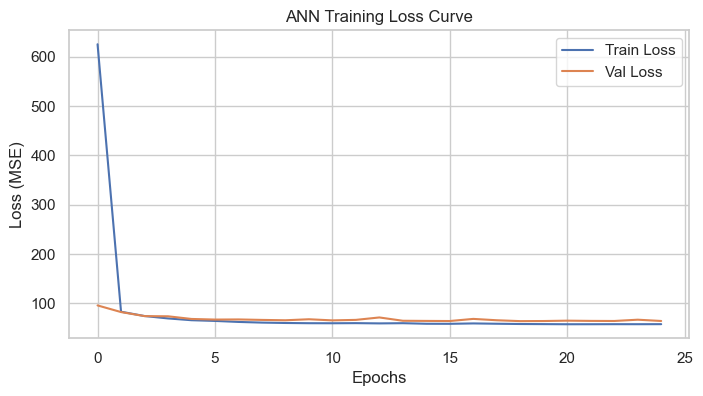

ANN -> MAE: 5.5390 | RMSE: 7.4551 | R2 Score: 0.6930


In [8]:
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_ann = ann_model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.15, verbose=1)
ann_pred = ann_model.predict(X_test).flatten()

# Simpan model (.h5)
ann_model.save('../models/ann_model.h5')

# Evaluasi metrik wajib
ann_mae = mean_absolute_error(y_test, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test, ann_pred))
ann_r2 = r2_score(y_test, ann_pred)

# Grafik Wajib: Training Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.title('ANN Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print(f"ANN -> MAE: {ann_mae:.4f} | RMSE: {ann_rmse:.4f} | R2 Score: {ann_r2:.4f}")

## [ALGORITMA 4: RECURRENT NEURAL NETWORK (LSTM)]
**Sel 9: Transformasi Sekuensial & Pelatihan Model Temporal**

LSTM adalah jenis arsitektur yang sangat diunggulkan dalam prediksi deret waktu (*time series*). Data latih sebelumnya di-*reshape* ke dalam struktur 3D (samples, time steps, features) untuk mengakomodir kebutuhan input sel *memory* LSTM.

Epoch 1/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1267.5360 - mae: 32.6906 - val_loss: 622.7560 - val_mae: 22.2172
Epoch 2/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 288.5817 - mae: 13.8712 - val_loss: 155.6404 - val_mae: 9.7799
Epoch 3/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 113.5993 - mae: 8.1853 - val_loss: 98.7114 - val_mae: 7.4827
Epoch 4/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 83.7757 - mae: 6.8712 - val_loss: 82.0127 - val_mae: 6.7113
Epoch 5/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 73.1342 - mae: 6.3412 - val_loss: 74.2662 - val_mae: 6.4064
Epoch 6/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.7577 - mae: 6.1177 - val_loss: 72.1289 - val_mae: 6.3021
Epoch 7/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 66.9038 - mae: 6.0360 - val_loss: 70.4648 - val_mae: 6.2259
Epoch 8/25
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 65.6297 - mae: 5.9783 - val_loss: 69.2138 - val_mae: 6.1498
Epoch 9/25
319/319 ━━━━━━━━━━━━

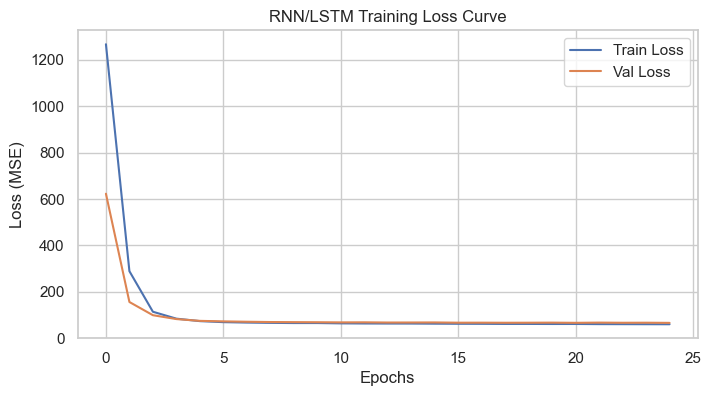

LSTM -> MAE: 5.5635 | RMSE: 7.5330 | MAPE: 14.79%


In [9]:
# Reshape dimensi input agar memenuhi standar sekuensial LSTM: [samples, time steps, features]
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    LSTM(32, activation='relu'),
    Dense(1, activation='linear')
])

def mape_metric(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_lstm = lstm_model.fit(X_train_lstm, y_train, epochs=25, batch_size=32, validation_split=0.15, verbose=1)
lstm_pred = lstm_model.predict(X_test_lstm).flatten()

# Simpan model (.h5)
lstm_model.save('../models/lstm_model.h5')

# Evaluasi metrik wajib
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_mape = mape_metric(y_test, lstm_pred)

# Grafik Wajib: Training Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('RNN/LSTM Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print(f"LSTM -> MAE: {lstm_mae:.4f} | RMSE: {lstm_rmse:.4f} | MAPE: {lstm_mape:.2f}%")

## [ALGORITMA 5: CUSTOM BACKPROPAGATION MODEL (NUMPY LURUS)]
**Sel 10: Pembuatan Arsitektur Jaringan Saraf Tiruan Tanpa Library Framework**

Tahap ini mengimplementasikan jaringan saraf secara manual dari nol (*from scratch*) tanpa bantuan modul canggih seperti Keras atau PyTorch. Kode berfokus pada operasi perkalian matriks, fungsi aktivasi (ReLU), dan perhitungan nilai gradien (*derivative*) untuk memperbarui bobot (W) dan bias (b) dalam mencari titik konvergensi *loss* terendah.

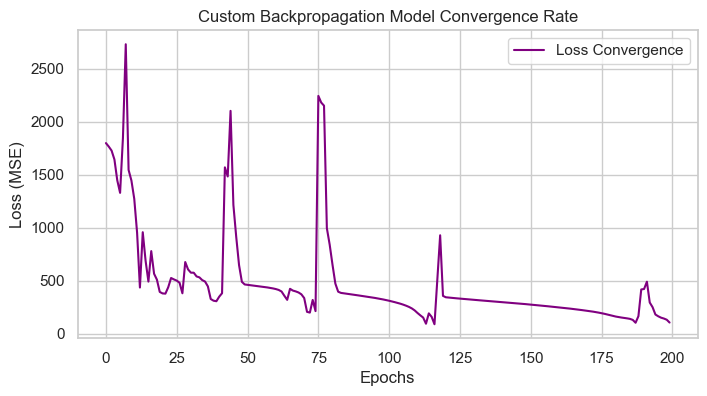

Custom Backpropagation -> MAE: 8.4912 | RMSE: 13.1089


In [10]:
class CustomBackpropagationRegressor:
    def __init__(self, input_size, hidden_size=16, seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))
        
    def relu(self, Z): return np.maximum(0, Z)
    def relu_derivative(self, Z): return Z > 0
    
    def fit_and_track_convergence(self, X, y, epochs=150, lr=0.005):
        y = y.reshape(-1, 1)
        loss_history = []
        
        for epoch in range(epochs):
            # 1. Forward Propagation
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self.relu(Z1)
            Z2 = np.dot(A1, self.W2) + self.b2
            predictions = Z2
            
            # Hitung Loss (MSE)
            loss = np.mean((predictions - y) ** 2)
            loss_history.append(loss)
            
            # 2. Backward Propagation (Hitung Turunan Manual)
            error = predictions - y
            dW2 = np.dot(A1.T, error) / len(y)
            db2 = np.sum(error, axis=0, keepdims=True) / len(y)
            
            dA1 = np.dot(error, self.W2.T)
            dZ1 = dA1 * self.relu_derivative(Z1)
            dW1 = np.dot(X.T, dZ1) / len(y)
            db1 = np.sum(dZ1, axis=0, keepdims=True) / len(y)
            
            # 3. Parameter Update (Gradient Descent Optimizer)
            self.W1 -= lr * dW1
            self.b1 -= lr * db1
            self.W2 -= lr * dW2
            self.b2 -= lr * db2
            
        return loss_history

    def predict(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        return (np.dot(A1, self.W2) + self.b2).flatten()

# Instansiasi & Pelatihan
bp_net = CustomBackpropagationRegressor(input_size=X_train.shape[1])
convergence_loss = bp_net.fit_and_track_convergence(X_train, y_train, epochs=200, lr=0.01)
bp_pred = bp_net.predict(X_test)

# Simpan parameter bobot numpy agar bisa diload di app.py produksi nanti
weights_dict = {'W1': bp_net.W1, 'b1': bp_net.b1, 'W2': bp_net.W2, 'b2': bp_net.b2}
joblib.dump(weights_dict, '../models/bp_weights.pkl')

bp_mae = mean_absolute_error(y_test, bp_pred)
bp_rmse = np.sqrt(mean_squared_error(y_test, bp_pred))

# Grafik Wajib: Convergence Rate
plt.figure(figsize=(8, 4))
plt.plot(convergence_loss, color='purple', label='Loss Convergence')
plt.title('Custom Backpropagation Model Convergence Rate')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print(f"Custom Backpropagation -> MAE: {bp_mae:.4f} | RMSE: {bp_rmse:.4f}")

## [BAB V: HASIL DAN PEMBAHASAN (ANALISIS KOMPARATIF)]
**Sel 11: Pembuatan Grafik Ringkasan Komparatif Evaluasi**

Tahap puncak komparasi seluruh algoritma yang telah di-*training*. Kita mengkonsolidasi skor tingkat kesalahan prediksi (MAE & RMSE). Semakin rendah skor pada grafik batang maupun garis di bawah, maka semakin tangguh arsitektur model tersebut dalam memprediksi tebalnya curah hujan.

--- TABEL PERBANDINGAN METRIK PERFORMA MODEL ---
            Model      MAE      RMSE
Linear Regression 5.726096  7.728547
              ANN 5.539006  7.455115
             LSTM 5.563499  7.533028
  Custom Backprop 8.491217 13.108931


C:\Users\brt\AppData\Local\Temp\ipykernel_13764\3913152662.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=summary_metrics, ax=ax1, palette='Blues_r')


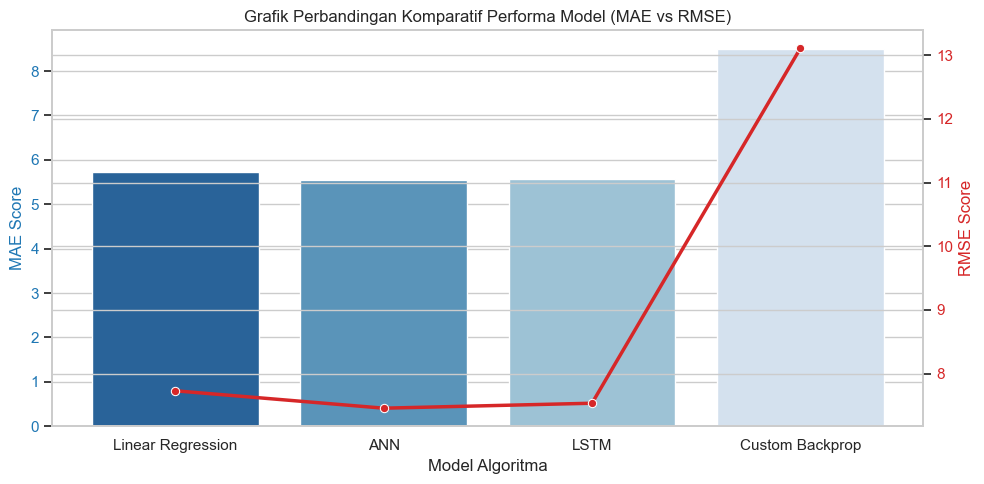

In [11]:
# Satukan hasil metrik evaluasi ke dalam satu Dataframe
summary_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'ANN', 'LSTM', 'Custom Backprop'],
    'MAE': [lr_mae, ann_mae, lstm_mae, bp_mae],
    'RMSE': [lr_rmse, ann_rmse, lstm_rmse, bp_rmse]
})

print("--- TABEL PERBANDINGAN METRIK PERFORMA MODEL ---")
print(summary_metrics.to_string(index=False))

# Grafik Komparatif Batang Utama (Deliverable Evaluasi Dosen)
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Model Algoritma')
ax1.set_ylabel('MAE Score', color=color)
sns.barplot(x='Model', y='MAE', data=summary_metrics, ax=ax1, palette='Blues_r')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('RMSE Score', color=color)
sns.lineplot(x='Model', y='RMSE', data=summary_metrics, ax=ax2, color=color, marker='o', sort=False, linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Grafik Perbandingan Komparatif Performa Model (MAE vs RMSE)')
fig.tight_layout()
plt.show()